In [6]:
# Install PyTorch (Standard CPU version is fine for learning)
%pip install torch

# Install DeepXDE
%pip install deepxde
%pip install numpy 

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.8/113.8 MB 3.0 MB/s eta 0:00:39
    --------------------------------------- 1.6/113.8 MB 3.4 MB/s eta 0:00:34
    --------------------------------------- 2.6/113.8 MB 3.8 MB/s eta 0:00:30
   - -------------------------------------- 3.1/113.8 MB 3.9 MB/s eta 0:00:29
   - -------------------------------------- 4.2/113.8 MB 3.8 MB/s eta 0:00:30
   - -------------------------------------- 5.5/113.8 MB 4.2 MB/s eta 0:00:27
   -- ------------------------------------- 6.3/113.8 MB 4.2 MB/s eta 0:00:26
   -- ------------------------------------- 7.3/113.8 MB 4.3 MB/s eta 0:00:25
   --- ------------------------------------ 8.7/113.8 MB 4.5 MB/s eta 0:00:24
   --- ------------------------------------ 9.4/113.8 MB 4.6 MB/s eta 0:00:23
   --- ------------------------------------ 10.7/113.8 MB 4.6 MB/s eta 0:00:23

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Using cached deepxde-1.15.0-py3-none-any.whl.metadata (12 kB)
  Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached pyaml-25.7.0-py3-none-any.whl.metadata (12 kB)
Using cached deepxde-1.15.0-py3-none-any.whl (195 kB)
Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl (107 kB)
Using cached pyaml-25.7.0-py3-none-any.whl (26 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.3 MB 1.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.3 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.3 MB 1.4 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.3 MB 1.4 MB/s eta 0:00:05
   ---------- -------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Note: you may need to restart the kernel to use updated packages.


Compiling and training...
Compiling model...
'compile' took 0.006995 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [3.40e-03, 2.06e-02, 6.34e-01]    [3.40e-03, 2.06e-02, 6.34e-01]    []  
1000      [1.85e-03, 6.82e-04, 1.34e-03]    [1.85e-03, 6.82e-04, 1.34e-03]    []  
2000      [3.33e-04, 1.56e-04, 2.16e-04]    [3.33e-04, 1.56e-04, 2.16e-04]    []  
3000      [2.09e-04, 5.22e-05, 8.72e-05]    [2.09e-04, 5.22e-05, 8.72e-05]    []  
4000      [1.40e-04, 2.65e-05, 4.53e-05]    [1.40e-04, 2.65e-05, 4.53e-05]    []  
5000      [1.08e-04, 1.68e-05, 2.68e-05]    [1.08e-04, 1.68e-05, 2.68e-05]    []  
6000      [8.88e-05, 1.24e-05, 1.77e-05]    [8.88e-05, 1.24e-05, 1.77e-05]    []  
7000      [7.47e-05, 1.00e-05, 1.28e-05]    [7.47e-05, 1.00e-05, 1.28e-05]    []  
8000      [6.34e-05, 8.13e-06, 9.74e-06]    [6.34e-05, 8.13e-06, 9.74e-06]    []  
9000      [5.47e-05, 6.92e-06, 7.80e-06]    [5.47e-05, 6.92e-06, 7.80e-0

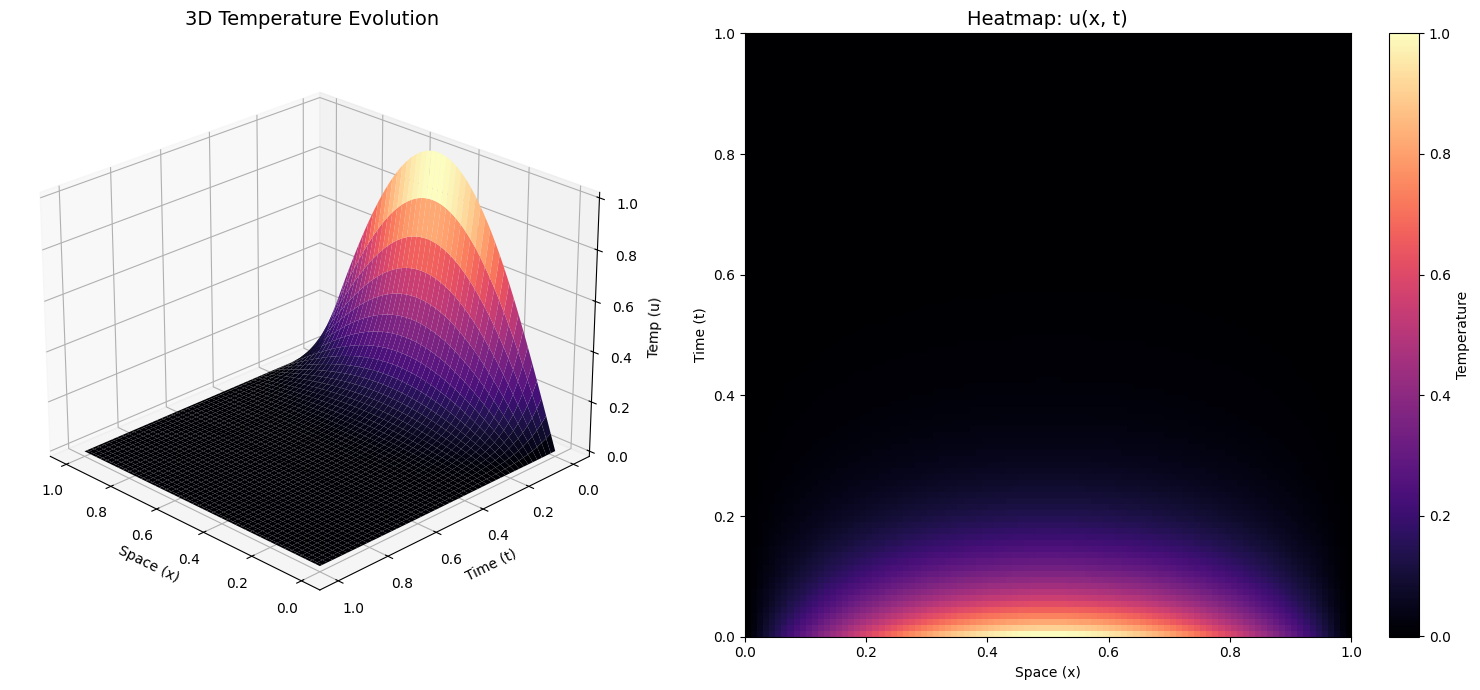

Temperature at x=0.5, t=0.5 is: 0.00719


In [9]:
import os

# 1. SET BACKEND TO PYTORCH
# This must be done BEFORE importing deepxde
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np
import torch

# 2. DEFINE THE PDE (The Heat Equation)
# Equation: du/dt = alpha * d^2u/dx^2
# We assume alpha = 1 for simplicity
def heat_equation(x, y):
    # x[:,0] is spatial distance (x)
    # x[:,1] is time (t)
    # y is the output temperature (u)
    
    # Calculate first derivative with respect to time (t is index 1)
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    
    # Calculate second derivative with respect to space (x is index 0)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    
    return dy_t - dy_xx

# 3. DEFINE GEOMETRY AND TIME DOMAIN
# Spatial domain: x in [0, 1]
geom = dde.geometry.Interval(0, 1)
# Time domain: t in [0, 1]
timedomain = dde.geometry.TimeDomain(0, 1)
# Combine them into 2D geometry (x, t)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# 4. DEFINE BOUNDARY & INITIAL CONDITIONS
# BC: Ends of the rod (x=0 and x=1) are held at temperature 0
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)

# IC: Initial temperature at t=0 is a sine wave: sin(pi * x)
ic = dde.icbc.IC(
    geomtime, 
    lambda x: np.sin(np.pi * x[:, 0:1]), 
    lambda _, on_initial: on_initial
)

# 5. BUILD THE DATA OBJECT
data = dde.data.TimePDE(
    geomtime, 
    heat_equation, 
    [bc, ic], 
    num_domain=2000,   # Training points inside the domain
    num_boundary=100,  # Training points on the edges
    num_initial=100    # Training points at t=0
)

# 6. BUILD THE NEURAL NETWORK
# Input layer: 2 neurons (x, t)
# Hidden layers: 3 layers with 32 neurons each, using Tanh activation
# Output layer: 1 neuron (temperature u)
net = dde.nn.FNN([2] + [32] * 3 + [1], "tanh", "Glorot normal")

model = dde.Model(data, net)

# 7. TRAIN THE MODEL
# We use Adam optimizer first for rough convergence, then L-BFGS for precision
print("Compiling and training...")
model.compile("adam", lr=1e-3)
model.train(iterations=10000)

print("Refining with L-BFGS...")
model.compile("L-BFGS")
losshistory, train_state = model.train()

# 8. PLOT RESULTS
# This will display the solution graph
# 8. ENHANCED VISUALIZATION
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a high-resolution grid for prediction (100x100 points)
x_space = np.linspace(0, 1, 100)
t_space = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_space, t_space)
predict_grid = np.vstack([X.ravel(), T.ravel()]).T

# Get model predictions
u_pred = model.predict(predict_grid)
U = u_pred.reshape(X.shape)

# Create a figure with two subplots: a 3D surface and a 2D Heatmap
fig = plt.figure(figsize=(16, 7))

# --- Subplot 1: 3D Surface Plot ---
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, T, U, cmap='magma', edgecolor='none', antialiased=True)
ax1.set_title("3D Temperature Evolution", fontsize=14)
ax1.set_xlabel("Space (x)")
ax1.set_ylabel("Time (t)")
ax1.set_zlabel("Temp (u)")
ax1.view_init(elev=25, azim=135) # Sets the best viewing angle

# --- Subplot 2: 2D Heatmap (Top-down view) ---
ax2 = fig.add_subplot(122)
im = ax2.imshow(U, extent=[0, 1, 0, 1], origin='lower', aspect='auto', cmap='magma')
ax2.set_title("Heatmap: u(x, t)", fontsize=14)
ax2.set_xlabel("Space (x)")
ax2.set_ylabel("Time (t)")
fig.colorbar(im, ax=ax2, label='Temperature')

plt.tight_layout()
plt.show()

# Final specific prediction
x_test_point = np.array([[0.5, 0.5]])
result = model.predict(x_test_point)
print(f"Temperature at x=0.5, t=0.5 is: {result[0][0]:.5f}")
